In [13]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report,confusion_matrix
import warnings
import pickle
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')

In [4]:
df = pd.read_csv("insurance_claims.csv")
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [ ]:
df.isna().any()

In [6]:
IQR=[]
IQR.append(df['age'].quantile(0.75)-df['age'].quantile(0.25))
IQR.append(df['policy_annual_premium'].quantile(0.75)-df['policy_annual_premium'].quantile(0.25))
IQR.append(df['umbrella_limit'].quantile(0.75)-df['umbrella_limit'].quantile(0.25))
IQR.append(df['total_claim_amount'].quantile(0.75)-df['total_claim_amount'].quantile(0.25))
IQR.append(df['property_claim'].quantile(0.75)-df['property_claim'].quantile(0.25))
IQR

[np.float64(12.0),
 np.float64(326.0875000000001),
 np.float64(0.0),
 np.float64(28780.0),
 np.float64(6440.0)]

In [7]:
upper=[]
upper.append(df['age'].quantile(0.75)+1.5*(IQR[0]))
upper.append(df['policy_annual_premium'].quantile(0.75)+1.5*(IQR[1]))
upper.append(df['umbrella_limit'].quantile(0.75)+1.5*(IQR[2]))
upper.append(df['total_claim_amount'].quantile(0.75)+1.5*(IQR[3]))
upper.append(df['property_claim'].quantile(0.75)+1.5*(IQR[4]))
upper

[np.float64(62.0),
 np.float64(1904.8262500000003),
 np.float64(0.0),
 np.float64(113762.5),
 np.float64(20545.0)]

In [15]:
df_num_features = df.select_dtypes(include=['int64','float64'])

months_as_customer


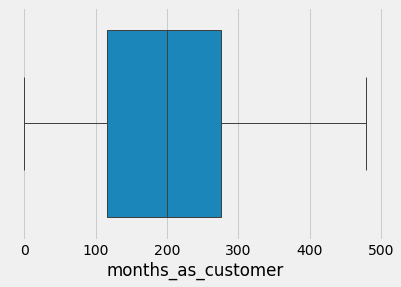

age


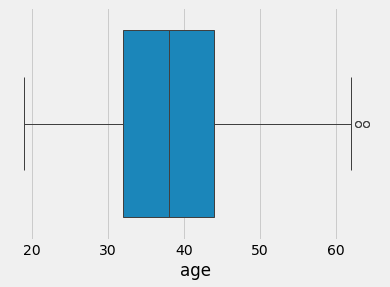

policy_number


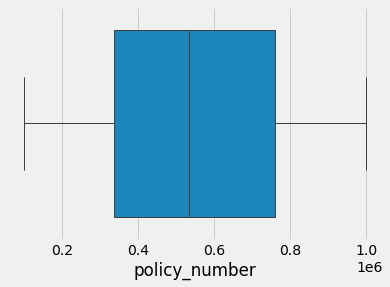

policy_deductable


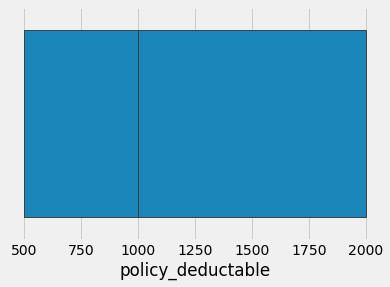

policy_annual_premium


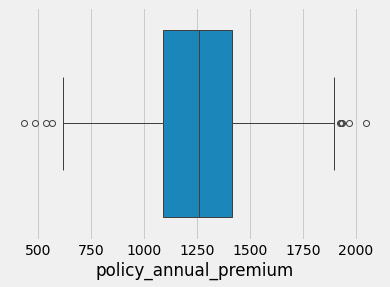

umbrella_limit


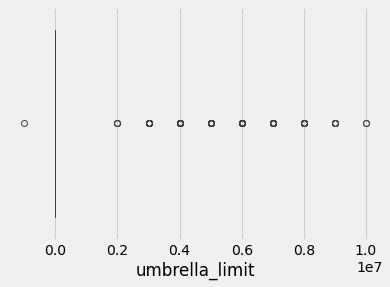

insured_zip


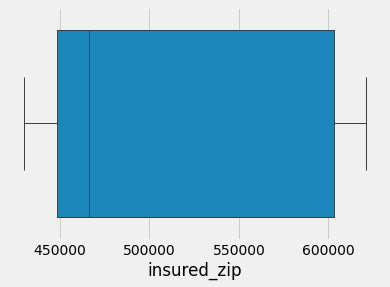

capital-gains


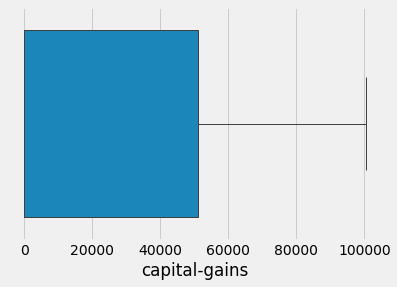

capital-loss


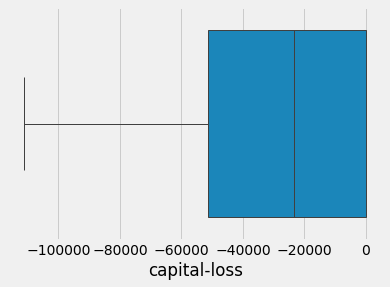

incident_hour_of_the_day


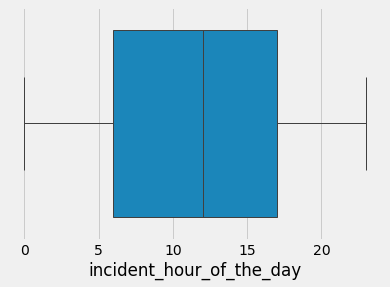

number_of_vehicles_involved


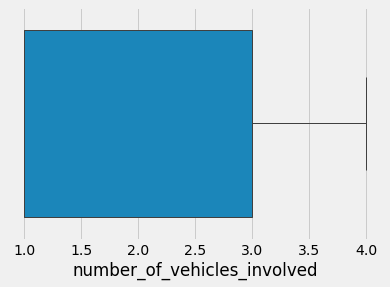

bodily_injuries


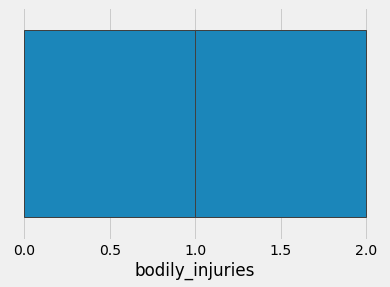

witnesses


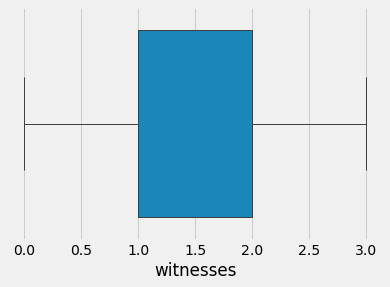

total_claim_amount


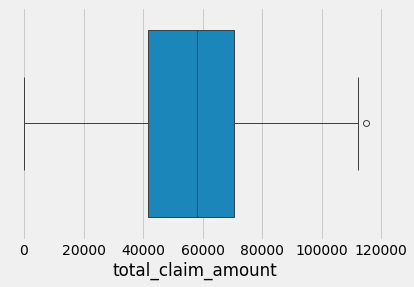

injury_claim


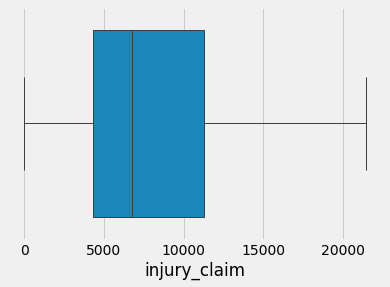

property_claim


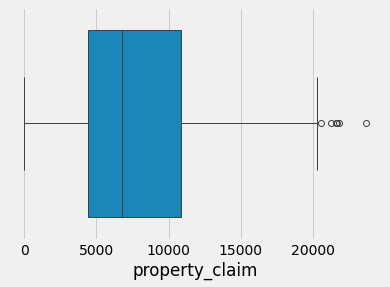

vehicle_claim


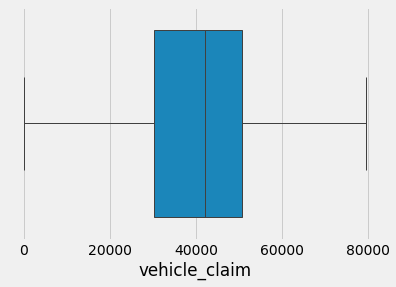

auto_year


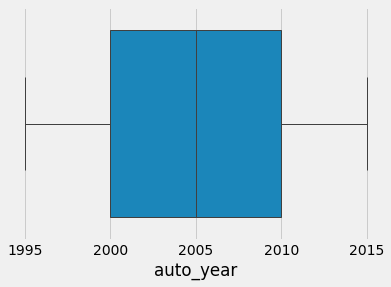

_c39


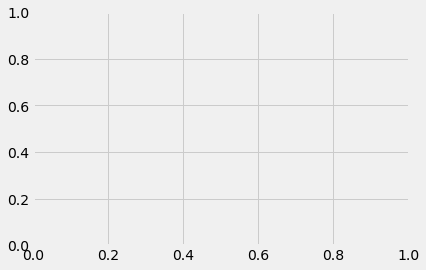

In [16]:
for col in df_num_features.columns:
    print(col)
    
    plt.figure()
    sns.boxplot(x=df_num_features[col].dropna())
    plt.show()

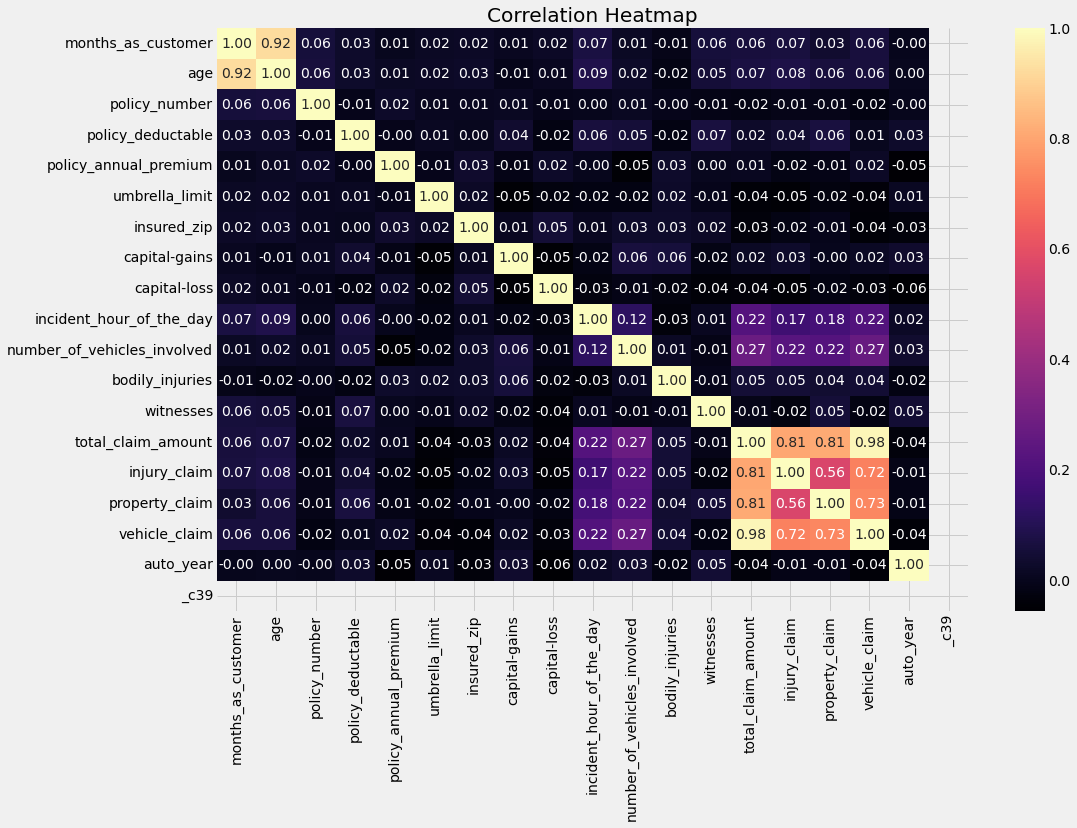

In [17]:
# select only numeric columns
df_num = df.select_dtypes(include=['int64','float64'])

# calculate correlation matrix
corr_matrix = df_num.corr()

# plot heatmap
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix, annot=True, cmap='magma', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()